In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv("/content/imputed_csv")
df.head(5)

,Unnamed: 0,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,flat,sector 36,0.82,3.0,2.0,2,2.0,New Property,908.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
1,1,flat,sector 89,0.95,2.0,2.0,2,4.0,New Property,1432.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0
2,3,flat,sohna road,0.32,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0
3,4,flat,sector 92,1.60,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0
4,5,flat,sector 102,0.48,2.0,2.0,1,5.0,Relatively New,630.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0


In [ ]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [ ]:
df.shape

(3234, 16)

<Axes: ylabel='luxury_score'>

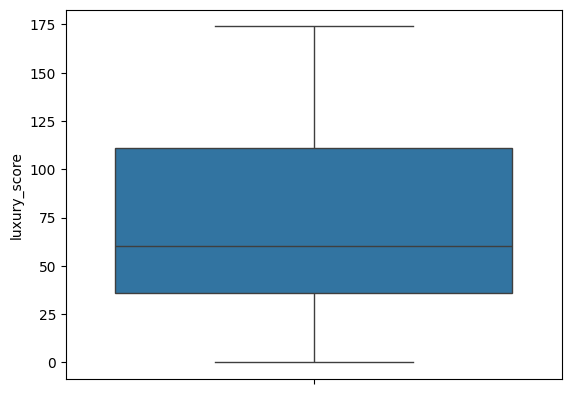

In [ ]:
sns.boxplot(df["luxury_score"])

In [ ]:
df["luxury_score"].describe()

,luxury_score
count,3234.000000
mean,73.227891
std,53.294538
min,0.000000
25%,36.000000
50%,60.000000
75%,111.000000
max,174.000000


In [ ]:
df["luxury_score"].quantile(0.36)

np.float64(49.0)

In [ ]:
df["luxury_score"].quantile(0.66)

np.float64(93.0)

In [ ]:
df["luxury_score"].quantile(0.99)

np.float64(174.0)

In [ ]:
def categorize_luxury_score(score):
    if score <= 49:
        return "Low"
    elif score <= 93:
        return "Medium"
    elif score <= 174:
        return "High"


In [ ]:
df["luxury_score"]=df['luxury_score'].apply(categorize_luxury_score)

In [ ]:
df["luxury_score"].value_counts()

,count
luxury_score,
Low,1425
High,1094
Medium,715


In [ ]:
df['floorNum'].describe()

,floorNum
count,3225.000000
mean,7.349767
std,6.111542
min,0.000000
25%,3.000000
50%,6.000000
75%,11.000000
max,45.000000


In [ ]:
def categorize_floor_num(x):
  if x<=2:
    return" Low Floor"
  elif x<=10:
    return "Medium Floor"
  elif x<=45:
    return "High Floor"
  else:
    return None

In [ ]:
df['floorNum']=df['floorNum'].apply(categorize_floor_num)

In [ ]:
df.head(5)

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 36,0.82,3.0,2.0,2,Low Floor,New Property,908.0,0.0,0.0,0.0,0.0,0.0,0.0,Low
1,flat,sector 89,0.95,2.0,2.0,2,Medium Floor,New Property,1432.0,1.0,1.0,0.0,0.0,0.0,0.0,Low
2,flat,sohna road,0.32,2.0,2.0,1,High Floor,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,Low
3,flat,sector 92,1.60,3.0,4.0,3+,Medium Floor,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,High
4,flat,sector 102,0.48,2.0,2.0,1,Medium Floor,Relatively New,630.0,0.0,0.0,1.0,0.0,0.0,0.0,High


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
categorical_cols=df.select_dtypes(include=['object']).columns

In [ ]:
categorical_cols

Index(['property_type', 'sector', 'balcony', 'floorNum', 'agePossession',
       'luxury_score'],
      dtype='object')

In [ ]:
data_label_encoded=df.copy()
for cols in categorical_cols:
  oe=OrdinalEncoder()
  data_label_encoded[cols]=oe.fit_transform(data_label_encoded[[cols]])



In [ ]:
x_label= data_label_encoded.drop("price",axis=1)
y_label= data_label_encoded["price"]


In [ ]:
data_label_encoded.corr(numeric_only=True)["price"]

,price
property_type,0.261669
sector,-0.203881
price,1.000000
bedRoom,0.599208
bathroom,0.620420
balcony,0.314499
floorNum,-0.013932
agePossession,-0.046473
built_up_area,0.814202
study room,0.124324


In [ ]:
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.model_selection import train_test_split

In [ ]:
# x_train,x_test,y_train,y_test=train_test_split()

In [ ]:
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(x_label,y_label)

RandomForestRegressor(random_state=42)

In [ ]:
rf.feature_importances_

array([0.00788265, 0.11942395, 0.01503644, 0.02027706, 0.01631376,
       0.00847241, 0.01205651, 0.75159965, 0.00793684, 0.00839686,
       0.00743008, 0.00304914, 0.00335008, 0.00931574, 0.00945884])

In [ ]:
f_f2=pd.DataFrame({
    'feature':x_label.columns,
    "importance":rf.feature_importances_
}).sort_values("importance",ascending=False)

In [ ]:
gb=GradientBoostingRegressor(random_state=42)
gb.fit(x_label,y_label)
Gb=pd.DataFrame({
    'feature':x_label.columns,
    "gb_importance":gb.feature_importances_
}).sort_values("gb_importance",ascending=False)


In [ ]:
f_f2

,feature,importance
7,built_up_area,0.751600
1,sector,0.119424
3,bathroom,0.020277
4,balcony,0.016314
2,bedRoom,0.015036
6,agePossession,0.012057
14,luxury_score,0.009459
13,furnishing_type,0.009316
5,floorNum,0.008472
9,servant room,0.008397


In [ ]:
Gb

,feature,gb_importance
7,built_up_area,0.786238
1,sector,0.117486
3,bathroom,0.037680
2,bedRoom,0.012078
10,store room,0.012002
0,property_type,0.010691
9,servant room,0.006536
13,furnishing_type,0.004408
8,study room,0.004270
4,balcony,0.004011


In [ ]:
from sklearn.inspection import permutation_importance

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x_label,y_label,test_size=0.2,random_state=42)

In [ ]:
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(x_label,y_label)

RandomForestRegressor(random_state=42)

In [ ]:
permuate_imp=permutation_importance(rf,x_label,y_label,n_repeats=30,random_state=42)

In [ ]:
p_imprtance=pd.DataFrame({
    'feature':x_label.columns,
    "permuate_importance":permuate_imp.importances_mean
}).sort_values("permuate_importance",ascending=False)

In [ ]:
from sklearn.feature_selection import RFE

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
estimator=RandomForestRegressor()

In [ ]:
selector_label=RFE(estimator,n_features_to_select=x_label.shape[1],step=1)
selector_label=selector_label.fit(x_label,y_label)

In [ ]:
selected_feature=x_label.columns[selector_label.support_]

In [ ]:
selected_coef=selector_label.estimator_.feature_importances_

In [ ]:
selected_coef

array([0.00760498, 0.12270879, 0.01759218, 0.02262518, 0.01539246,
       0.00894202, 0.0126845 , 0.74540873, 0.00609789, 0.00757992,
       0.00695667, 0.00326771, 0.00391289, 0.00917938, 0.01004669])

In [ ]:
Rfe=pd.DataFrame({
    'feature':x_label.columns,
    "RFE_importance":selected_coef
}).sort_values("RFE_importance",ascending=False)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lr=LinearRegression()

In [ ]:
lr.fit(x_train,y_train)
lr.coef_

array([ 0.43768589, -0.00322295,  0.06087328,  0.14192848,  0.00266076,
       -0.02559823,  0.01376522,  0.00088029,  0.15334204,  0.14900526,
        0.23558114, -0.04334891, -0.11837972,  0.19995772, -0.01036934])

In [ ]:
lr_imp=pd.DataFrame({
    'feature':x_label.columns,
    "lr_importance":lr.coef_
}).sort_values("lr_importance",ascending=False)

In [ ]:
whole=lr_imp.merge(Rfe,on="feature").merge(p_imprtance,on="feature").merge(f_f2,on="feature").merge(Gb,on="feature").set_index('feature')

In [ ]:
new_calc=whole/whole.sum()

In [ ]:
new_calc.mean(axis=1).sort_values(ascending=False)

,0
feature,
built_up_area,0.599437
sector,0.106056
property_type,0.080600
store room,0.045660
bathroom,0.044530
furnishing_type,0.039341
servant room,0.031517
study room,0.030571
bedRoom,0.021956


In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
new=whole.drop(columns="lr_importance")

In [ ]:
new=new/new.sum()

In [ ]:
new.mean(axis=1).sort_values(ascending=False)

,0
feature,
built_up_area,0.749112
sector,0.133245
bathroom,0.025965
bedRoom,0.014707
balcony,0.012463
property_type,0.009166
agePossession,0.008951
servant room,0.008218
store room,0.007780


In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(x_label,y_label)

RandomForestRegressor(random_state=42)

In [ ]:
score=np.mean(cross_val_score(rf,x_label,y_label,cv=10,scoring="r2"))

In [ ]:
score

np.float64(0.8219357568762617)

In [ ]:
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)
np.mean(cross_val_score(rf,x_label.drop(columns=['pooja room','floorNum',"others"]),y_label,cv=10,scoring="r2"))


np.float64(0.8227544581443086)

In [ ]:
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)
np.mean(cross_val_score(rf,x_label.drop(columns=['pooja room',"others"]),y_label,cv=10,scoring="r2"))


np.float64(0.8216929481115652)

In [ ]:
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)
np.mean(cross_val_score(rf,x_label.drop(columns=['pooja room',"floorNum"]),y_label,cv=10,scoring="r2"))


np.float64(0.8249824956513777)

In [ ]:
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)
np.mean(cross_val_score(rf,x_label.drop(columns=['floorNum',"others"]),y_label,cv=10,scoring="r2"))


np.float64(0.8222786585126206)

In [ ]:
export_data=df.to_csv("selection")